In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

Opening the predictors files

In [3]:
training_experiment='ESD_pseudo_reality'
if training_experiment == 'ESD_pseudo_reality':
    period_training = '1961-1980'
elif training_experiment == 'Emulator_hist_future':
    period_training = '1961-1980_2080-2099'


domain ='ALPS'
if domain == 'ALPS':
    gcm_name = 'CNRM-CM5'

predictor_filename = f'/leonardo_work/ICT25_ESP/sdigioia/CORDEX-ML/CORDEX-domains/ALPS_domain/train/{training_experiment}/predictors/{gcm_name}_{period_training}.nc'
predictor = xr.open_dataset(predictor_filename)


In [5]:

target_filename=f'/leonardo_work/ICT25_ESP/sdigioia/CORDEX-ML/CORDEX-domains/ALPS_domain/train/{training_experiment}/target/pr_tasmax_CNRM-CM5_{period_training}.nc'
predictand=xr.open_dataset(target_filename)

In [6]:
print(predictor)

/leonardo/pub/userexternal/sdigioia/sdigioia/env/RLenv/lib/python3.10/site-packages/dask/array/chunk_types.py:110: UserWarning: 
--------------------------------------------------------------------------------

  CuPy may not function correctly because multiple CuPy packages are installed
  in your environment:

    cupy, cupy-cuda11x

  Follow these steps to resolve this issue:

    1. For all packages listed above, run the following command to remove all
       existing CuPy installations:

         $ pip uninstall <package_name>

      If you previously installed CuPy via conda, also run the following:

         $ conda uninstall cupy

    2. Install the appropriate CuPy package.
       Refer to the Installation Guide for detailed instructions.

         https://docs.cupy.dev/en/stable/install.html

--------------------------------------------------------------------------------

  import cupy


<xarray.Dataset>
Dimensions:  (time: 7305, lat: 16, lon: 16)
Coordinates:
  * time     (time) datetime64[ns] 1961-01-01T12:00:00 ... 1980-12-31T12:00:00
  * lon      (lon) float64 -4.0 -2.0 0.0 2.0 4.0 ... 18.0 20.0 22.0 24.0 26.0
  * lat      (lat) float64 32.0 34.0 36.0 38.0 40.0 ... 54.0 56.0 58.0 60.0 62.0
Data variables: (12/15)
    u_850    (time, lat, lon) float32 ...
    u_700    (time, lat, lon) float32 ...
    u_500    (time, lat, lon) float32 ...
    v_850    (time, lat, lon) float32 ...
    v_700    (time, lat, lon) float32 ...
    v_500    (time, lat, lon) float32 ...
    ...       ...
    t_850    (time, lat, lon) float32 ...
    t_700    (time, lat, lon) float32 ...
    t_500    (time, lat, lon) float32 ...
    z_850    (time, lat, lon) float32 ...
    z_700    (time, lat, lon) float32 ...
    z_500    (time, lat, lon) float32 ...
Attributes: (12/28)
    CDI:                            Climate Data Interface version 2.4.4 (htt...
    Conventions:                    CF-1.

In [7]:
print(predictand)

<xarray.Dataset>
Dimensions:  (time: 7305, y: 128, x: 128)
Coordinates:
  * time     (time) datetime64[ns] 1961-01-01T12:00:00 ... 1980-12-31T12:00:00
    lon      (y, x) float64 ...
    lat      (y, x) float64 ...
  * x        (x) float64 2.062e+03 2.075e+03 2.088e+03 ... 3.638e+03 3.65e+03
  * y        (y) float64 1.412e+03 1.425e+03 1.438e+03 ... 2.988e+03 3e+03
Data variables:
    tasmax   (time, y, x) float32 ...
    pr       (time, y, x) float32 ...
Attributes: (12/26)
    description:                    Created by xios
    title:                          Created by xios
    Conventions:                    CF-1.6
    creation_date:                  2018-10-24T11:26:47Z
    name:                           EUR-11_CNRM-CERFACS-CNRM-CM5_historical_r...
    institute_id:                   CNRM
    ...                             ...
    references:                     http://www.umr-cnrm.fr/spip.php?article12...
    comment:                        CORDEX Europe EUR-11 CNRM-ALADIN 6.3 

In [17]:
print(predictand.dims)
print(predictand.attrs)
print(predictand.coords)
print(predictand.data_vars.keys())


Frozen({'time': 7305, 'y': 128, 'x': 128})
{'description': 'Created by xios', 'title': 'Created by xios', 'Conventions': 'CF-1.6', 'creation_date': '2018-10-24T11:26:47Z', 'name': 'EUR-11_CNRM-CERFACS-CNRM-CM5_historical_r1i1p1_CNRM-ALADIN63_v2_day', 'institute_id': 'CNRM', 'institution': 'CNRM (Centre National de Recherches Meteorologiques, Toulouse 31057, France)', 'model_id': 'CNRM-ALADIN63', 'experiment_id': 'historical', 'experiment': 'Historical run with GCM forcing', 'contact': 'contact.aladin-cordex@meteo.fr', 'product': 'output', 'Convention': 'CF-1.6', 'driving_model_id': 'CNRM-CERFACS-CNRM-CM5', 'driving_model_ensemble_member': 'r1i1p1', 'driving_experiment_name': 'historical', 'driving_experiment': 'CNRM-CERFACS-CNRM-CM5, historical, r1i1p1', 'rcm_version_id': 'v2', 'project_id': 'CORDEX', 'CORDEX_domain': 'EUR-11', 'references': 'http://www.umr-cnrm.fr/spip.php?article125&lang=en', 'comment': 'CORDEX Europe EUR-11 CNRM-ALADIN 6.3 L91 CNRM-CERFACS-CNRM-CM5: EUC12v63-2.02. R

In [18]:
predictand.tasmax

<xarray.DataArray 'tasmax' (time: 7305, y: 128, x: 128)>
[119685120 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 1961-01-01T12:00:00 ... 1980-12-31T12:00:00
    lon      (y, x) float64 2.152 2.288 2.423 2.559 ... 21.68 21.86 22.03 22.21
    lat      (y, x) float64 36.52 36.54 36.55 36.56 ... 50.55 50.53 50.51 50.5
  * x        (x) float64 2.062e+03 2.075e+03 2.088e+03 ... 3.638e+03 3.65e+03
  * y        (y) float64 1.412e+03 1.425e+03 1.438e+03 ... 2.988e+03 3e+03
Attributes:
    standard_name:       air_temperature
    long_name:           Daily Maximum Near-Surface Air Temperature
    units:               K
    online_operation:    average
    interval_operation:  1 d
    interval_write:      1 d
    cell_methods:        time: maximum
    grid_mapping:        Lambert_Conformal
    coordinates:         lon lat height

In [19]:
predictand.pr

<xarray.DataArray 'pr' (time: 7305, y: 128, x: 128)>
[119685120 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 1961-01-01T12:00:00 ... 1980-12-31T12:00:00
    lon      (y, x) float64 2.152 2.288 2.423 2.559 ... 21.68 21.86 22.03 22.21
    lat      (y, x) float64 36.52 36.54 36.55 36.56 ... 50.55 50.53 50.51 50.5
  * x        (x) float64 2.062e+03 2.075e+03 2.088e+03 ... 3.638e+03 3.65e+03
  * y        (y) float64 1.412e+03 1.425e+03 1.438e+03 ... 2.988e+03 3e+03

In [22]:
import numpy as np
arr_pr=predictand.pr.to_numpy()

print("precipitation maximum:",np.max(arr_pr))
print("precipitation minimum:",np.min(arr_pr))
print("precipitation minimum:",np.mean(arr_pr))

precipitation maximum: 339.8424
precipitation minimum: 0.0
precipitation minimum: 3.0094461


In [8]:
def plot_predictor_map(predictor, var_name, domain, time_index=0, figsize=(8,8), cmap='viridis'):
    data_to_plot = predictor[var_name].isel(time=time_index)

    central_longitude = 180 if domain == 'NZ' else 0 if domain == 'ALPS' else None

    plt.figure(figsize=figsize)
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=central_longitude))

    data_to_plot.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmap)

    ax.coastlines(resolution='10m')
    ax.add_feature(cfeature.BORDERS, linestyle=':')

    plt.title(f'Variable {var_name} from predictor set ({domain}) for time step {time_index}')
    plt.show()


def plot_predictand_map(predictand, var_name, domain, time_index, figsize=(8,8), cmap='viridis'):
    data_to_plot = predictand[var_name].isel(time=time_index)

    central_longitude = 180 if domain == 'NZ' else 0 if domain == 'ALPS' else None

    plt.figure(figsize=figsize)
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=central_longitude))

    if (domain == 'NZ') or (domain == 'SA'):
        data_to_plot.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmap)
    elif domain == 'ALPS':
        cs = ax.pcolormesh(data_to_plot['lon'], data_to_plot['lat'],
                           data_to_plot,
                           transform=ccrs.PlateCarree(),
                           cmap=cmap)

    ax.coastlines(resolution='10m')
    ax.add_feature(cfeature.BORDERS, linestyle=':')

    plt.title(f'Variable {var_name} from predictand set ({domain}) for time step {time_index}')
    plt.show()

In [9]:
plot_predictor_map(predictor=predictor, var_name='v_850', domain=domain, cmap='RdBu_r')

/leonardo/pub/userexternal/sdigioia/sdigioia/env/RLenv/lib/python3.10/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


URLError: <urlopen error [Errno 101] Network is unreachable>

<Figure size 800x800 with 2 Axes>

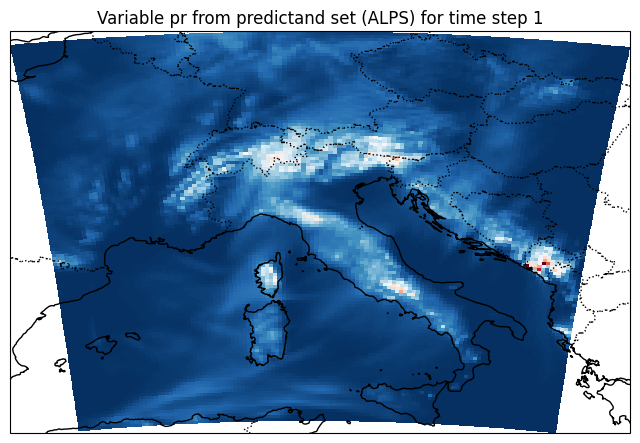

In [ ]:
plot_predictand_map(predictand=predictand, var_name='pr',time_index=1, domain=domain, cmap='RdBu_r')

In [10]:
min_lat_highres= predictand['lat'].min().item()
max_lat_highres= predictand['lat'].max().item()
min_lon_highres= predictand['lon'].min().item()
max_lon_highres= predictand['lon'].max().item()

In [11]:
print(min_lat_highres, max_lat_highres)

36.4599838233941 51.07355677206944


In [12]:
min_lat_lowres= predictor['lat'].min().item()
max_lat_lowres= predictor['lat'].max().item()
min_lon_lowres= predictor['lon'].min().item()
max_lon_lowres= predictor['lon'].max().item()

In [13]:
print(min_lat_lowres, max_lat_lowres)

32.0 62.0


In [ ]:
orog_path =  f'/content/Static_fields.nc'
orog = xr.open_dataset(orog_path)[['orog']]

In [ ]:
sliced_predictor = predictor.sel(lat=slice(min_lat_highres, max_lat_highres), lon=slice(min_lon_highres, max_lon_highres))

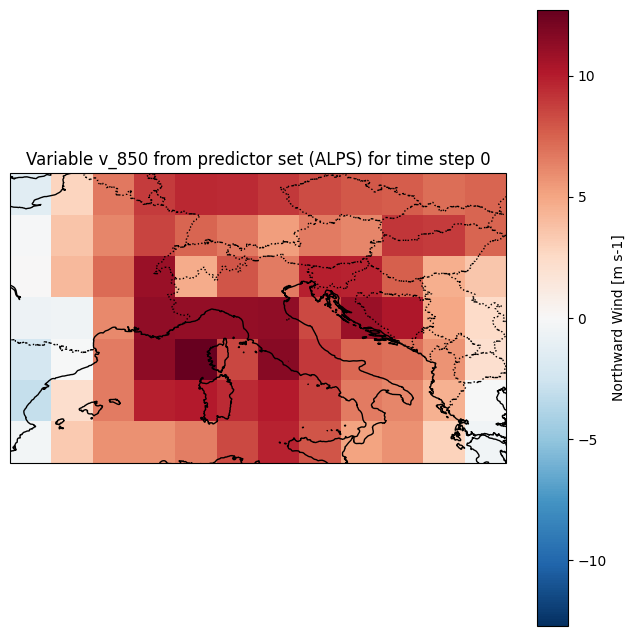

In [ ]:
plot_predictor_map(predictor=sliced_predictor, var_name='v_850', domain=domain, cmap='RdBu_r')

In [ ]:
orog

<xarray.Dataset> Size: 330kB
Dimensions:  (y: 128, x: 128)
Coordinates:
  * y        (y) float64 1kB 1.412e+03 1.425e+03 1.438e+03 ... 2.988e+03 3e+03
  * x        (x) float64 1kB 2.062e+03 2.075e+03 ... 3.638e+03 3.65e+03
    lon      (y, x) float64 131kB ...
    lat      (y, x) float64 131kB ...
Data variables:
    orog     (y, x) float32 66kB ...
Attributes: (12/26)
    description:                    Created by xios
    title:                          Created by xios
    Conventions:                    CF-1.6
    creation_date:                  2018-11-12T08:28:52Z
    tracking_id:                    hdl:21.14103/30495a86-afa0-43d6-9017-fa76...
    name:                           EUR-11_CNRM-CERFACS-CNRM-CM5_historical_r...
    ...                             ...
    CORDEX_domain:                  EUR-11
    references:                     http://www.umr-cnrm.fr/spip.php?article12...
    comment:                        CORDEX Europe EUR-11 CNRM-ALADIN 6.3 L91 ...
    c3s_disclaimer:                 This data has been produced in the contex...
    driving_experiment_comment:     Known issue correction: this simulation (...
    frequency:                      fx

In [ ]:
#create a mask to extract the low-resolution domain covered by the high-resolution image from predictors



In [ ]:


def plot_orog_map(orog, domain, figsize=(8,8), cmap='terrain'):
    data_to_plot = orog['orog']

    central_longitude = 180 if domain == 'NZ' else 0 if domain == 'ALPS' else None

    plt.figure(figsize=figsize)
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=central_longitude))

    if (domain == 'NZ') or (domain == 'SA'):
        data_to_plot.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmap)
    elif domain == 'ALPS':
        cs = ax.pcolormesh(data_to_plot['lon'], data_to_plot['lat'],
                           data_to_plot,
                           transform=ccrs.PlateCarree(),
                           cmap=cmap)

    ax.coastlines(resolution='10m')
    ax.add_feature(cfeature.BORDERS, linestyle=':')

    plt.title(f'Orography ({domain})')
    plt.show()

In [ ]:
import netCDF4 as nc

write_log('\nStarting the preprocessing of the low resolution data.', args, accelerator=None, mode='a')
with nc.Dataset(predictor_filename) as ds:
     for p_idx, p in enumerate(predictor.data_vars):
            data = ds[p][:]
            if p_idx == 0: # first parameter being processed -> get dimensions and initialize the input dataset
                try:
                    lat_low = ds['latitude'][:]
                    lon_low = ds['longitude'][:]
                except:
                    lat_low = ds['lat'][:]
                    lon_low = ds['lon'][:]
                lat_dim = len(lat_low)
                lon_dim = len(lon_low)
                time_dim = len(ds['time'])
                input_ds = np.zeros((time_dim, n_params, args.n_levels_low, lat_dim, lon_dim), dtype=np.float32) # time, variables, levels, lat, lon
        input_ds[:, p_idx,:,:,:] = data